## Chapter 10 - Applied

### Question 6

In [1]:
# Book's imports
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression,
    Lasso
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

# Torch imports
import torch
from torch import nn
from torch.optim import RMSprop
from torch.utils.data import TensorDataset
from torchmetrics import (
    MeanAbsoluteError,
    MeanSquaredError,
    R2Score
)
from torchinfo import summary
from torchvision.io import read_image
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning import seed_everything
seed_everything(0, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)

Seed set to 0


In [2]:
# Import datasets, models & transforms
from torchvision.datasets import MNIST, CIFAR100
from torchvision.models import (
    resnet50,
    ResNet50_Weights,
    efficientnet_v2_m,
    EfficientNet_V2_M_Weights
)
from torchvision.transforms import(
    Resize,
    Normalize,
    CenterCrop,
    ToTensor
)

In [3]:
# Import some ISLP helper functions
from ISLP.torch import (
    SimpleDataModule,
    SimpleModule,
    ErrorTracker,
    rec_num_workers
)
from ISLP.torch.imdb import (
    load_lookup,
    load_tensor,
    load_sparse,
    load_sequential
)

/home/andrey/venvs/islp/lib/python3.12/site-packages/ISLP/torch/imdb.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [4]:
# Utility imports
from glob import glob
import json
from IPython.display import display, Markdown
from datetime import datetime
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import os

#### 6a)

In [5]:
# Select a sample of betas
betas = np.linspace(-6, 6, 100)

# Create a dataset
y = np.sin(betas) + betas/10

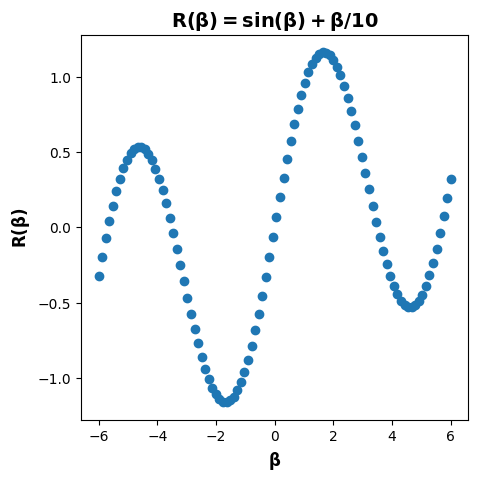

In [6]:
# Plots arguments
title_args = {
    'fontsize': 14,
    'fontweight': 'bold'
}
label_args = {
    'fontsize': 12,
    'fontweight': 'bold'
}

# Plot
ax = subplots(figsize=(5,5))[1]
ax.scatter(betas, y)
ax.set_title(r'$\mathbf{R(\beta) = sin(\beta) + \beta/10}$', **title_args)
ax.set_xlabel(r'$\mathbf{\beta}$', **label_args)
ax.set_ylabel(r'$\mathbf{R(\beta)}$', **label_args);

#### 6b)

The derivative of the function is:

$$\frac{d}{d\beta}(sin(\beta) + \beta/10) = cos(\beta) + 1/10$$

#### 6c)

In [7]:
# Learning rate
lr = 0.1

# Starting point
beta = 2.3

# Store points
beta_list = []
beta_list.append(beta)

# Choose maximum iterations
n = 100
for i in range(n):
    # Compute derivative
    derivative = np.cos(beta) + 1/10

    # Break if lr*derivative is too small
    if abs(lr*derivative) < 0.001:
        break

    # Update beta
    beta = beta - lr*derivative

    # Update betas_list
    beta_list.append(beta)

# Compute y for betas_list
y_ = np.sin(beta_list) + np.asarray(beta_list)/10

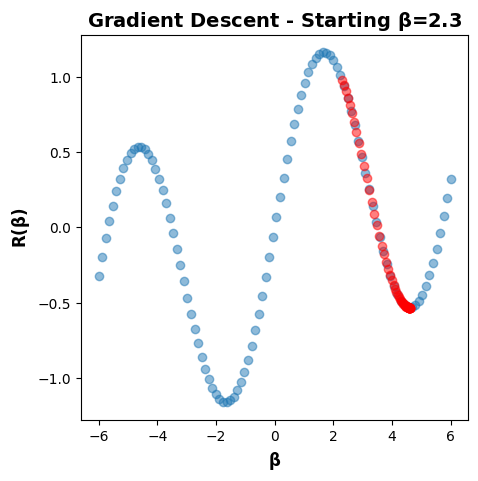

In [8]:
# Plot
ax = subplots(figsize=(5,5))[1]
ax.scatter(betas, y, alpha=0.5)
ax.set_title(r'Gradient Descent - Starting $\mathbf{\beta}$=2.3', **title_args)
ax.set_xlabel(r'$\mathbf{\beta}$', **label_args)
ax.set_ylabel(r'$\mathbf{R(\beta)}$', **label_args)
ax.scatter(beta_list, y_, c='r', alpha=0.5);

In [9]:
# Get report values
beta_start = beta_list[0]
y_start = y_[0]
iterations = len(y_)

# Report text
text = f"""
<br>

The plot displays the original function in **blue** and the gradient descent iterations \
in **red**, illustrating the path toward a local minimum.

When performing **gradient descent** on the function $R(\\beta) = sin(\\beta) + \\beta/10$ with a \
starting with $\\beta$ = {beta_start} and learning rate of {lr:.1f}, we reach a local minimum after {iterations} iterations. At this point \
the parameter $\\beta$ stops updating significantly (<0.001).

<br>
"""

# Show text
display(Markdown(text))


<br>

The plot displays the original function in **blue** and the gradient descent iterations in **red**, illustrating the path toward a local minimum.

When performing **gradient descent** on the function $R(\beta) = sin(\beta) + \beta/10$ with a starting with $\beta$ = 2.3 and learning rate of 0.1, we reach a local minimum after 63 iterations. At this point the parameter $\beta$ stops updating significantly (<0.001).

<br>


#### 6d)

In [10]:
# Starting point
beta = 1.4

# Keep track of betas
beta_list = []
beta_list.append(beta)

for i in range(n):
    # Compute derivative
    derivative = np.cos(beta) + 1/10

    # Break if lr*derivative is too small
    if lr*derivative < 0.001:
        break

    # Update beta
    beta = beta - lr*derivative

    # Update beta_list
    beta_list.append(beta)

y_ = np.sin(beta_list) + np.asarray(beta_list)/10

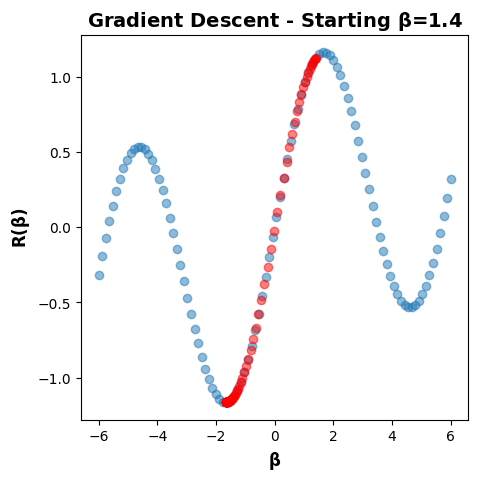

In [11]:
# Plot
ax = subplots(figsize=(5,5))[1]
ax.scatter(betas, y, alpha=0.5)
ax.set_title(r'Gradient Descent - Starting $\mathbf{\beta}$=1.4', **title_args)
ax.set_xlabel(r'$\mathbf{\beta}$', **label_args)
ax.set_ylabel(r'$\mathbf{R(\beta)}$', **label_args)
ax.scatter(beta_list, y_, c='r', alpha=0.5);

In [95]:
# Get report values
beta_start = beta_list[0]
y_start = y_[0]
iterations = len(y_)

# Report text
text = f"""
<br>

This time, starting from $\\beta$ = {beta_start}, **gradient descent** converges to the \
global minimum by reversing direction compared to the previous run. The process completes \
after {iterations} iterations.
"""

# Show text
display(Markdown(text))


<br>

This time, starting from $\beta$ = 1.4, **gradient descent** converges to the global minimum by reversing direction compared to the previous run. The process completes after 73 iterations.


---

### Question 7

My initial thoughts on this question are that a single hidden layer followed by dropout regularization will perform similarly to a linear logistic regression with regularization, such as Lasso. Lasso can shrink some parameters to zero, which has some resemblance to dropout.

So, in order to try a slight different behaviour, we should implement a ReLU activation function to introduce and test some nonlinear effects in the model.

In [203]:
# Load dataset
default = pd.read_csv('data/Default.csv')

# Get dummies
default = pd.get_dummies(default, drop_first=True, dtype='int')

# Adapt column names
default.columns = [x.lower() for x in default.columns]

In [204]:
# Get features and response
X = default.drop(columns='default_yes')
y = default['default_yes']

# Split the dataset
X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.3, random_state=0, shuffle=True)

# Create 'val' and 'test' datasets
X_val, X_test, y_val, y_test = train_test_split(X_, y_, test_size=0.5, random_state=0, shuffle=True)

In [231]:
# Columns to standardize
columns = ['balance', 'income']

# Standardize the data
scaler = StandardScaler(with_mean=True, with_std=True)
scaler.fit(X_train[columns])
X_train_s = np.column_stack((scaler.transform(X_train[columns]), np.array(X_train['student_yes'])))
X_val_s = np.column_stack((scaler.transform(X_val[columns]), np.array(X_val['student_yes'])))
X_test_s = np.column_stack((scaler.transform(X_test[columns]), np.array(X_test['student_yes'])))

# Create tensor features
X_train_t = torch.tensor(X_train_s.astype(np.float32))
X_val_t = torch.tensor(X_val_s.astype(np.float32))
X_test_t = torch.tensor(X_test_s.astype(np.float32))

# Create tensor response
y_train_t = torch.tensor(np.array(y_train).astype(np.float32))
y_val_t = torch.tensor(np.array(y_val).astype(np.float32))
y_test_t = torch.tensor(np.array(y_test).astype(np.float32))

# Create tensor datasets
default_train = TensorDataset(X_train_t, y_train_t)
default_val = TensorDataset(X_val_t, y_val_t)
default_test = TensorDataset(X_test_t, y_test_t)

In [232]:
# Model architecture
class model_linear(nn.Module):
    def __init__(self, input_size):
        super(model_linear, self).__init__()
        self.flatten = nn.Flatten()
        self.sequential = nn.Sequential(
            nn.Linear(input_size, 10),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(10, 1)
        )

    def forward(self, x):
        return self.sequential(x).squeeze(1)

# Instantiate the model
model = model_linear(X_train_s.shape[1])

# Get model's summary
summary(
    model=model,
    input_size=X_train_t.shape,
    col_names=['input_size', 'output_size', 'num_params'],
    col_width=14
)

Layer (type:depth-idx)                   Input Shape    Output Shape   Param #
model_linear                             [7000, 3]      [7000]         --
├─Sequential: 1-1                        [7000, 3]      [7000, 1]      --
│    └─Linear: 2-1                       [7000, 3]      [7000, 10]     40
│    └─ReLU: 2-2                         [7000, 10]     [7000, 10]     --
│    └─Dropout: 2-3                      [7000, 10]     [7000, 10]     --
│    └─Linear: 2-4                       [7000, 10]     [7000, 1]      11
Total params: 51
Trainable params: 51
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.36
Input size (MB): 0.08
Forward/backward pass size (MB): 0.62
Params size (MB): 0.00
Estimated Total Size (MB): 0.70

In [ ]:
# Variables
max_num_workers = 16
batch_size = 100

# Data Module - Simplified 'DataLoader'
default_dm = SimpleDataModule(
    default_train,
    default_val,
    batch_size=batch_size,
    num_workers=min(4, max_num_workers),
    validation=default_val
)

# Set up helper model module
default_module = SimpleModule.binary_classification(model)

# Log the results
default_logger = CSVLogger('logs', name='default')

# Create a trainer
default_trainer = Trainer(
    deterministic=True,
    max_epochs=50,
    log_every_n_steps=5,
    logger=default_logger,
    callbacks=[ErrorTracker()]
)

# Fit/train
default_trainer.fit(default_module, datamodule=default_dm)

In [234]:
# Check 'val' performance
default_trainer.test(default_module, datamodule=default_dm)

Testing: |                                                | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.9673333168029785
        test_loss           0.08691544830799103
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.08691544830799103, 'test_accuracy': 0.9673333168029785}]

In [268]:
# Predict on 'test' dataset
model.eval()
preds_test = model(X_test_t)

# Apply a softmax to the logits
preds_probs = np.exp(np.asarray(preds_test.detach())) # detach to turn into ndarray
preds = np.where(1, preds_probs>0.5, 0)

# Get accuracy
accuracy_score(y_test, preds)

0.972

In [269]:
# Generate a confusion matrix on 'test'
confusion_matrix(y_test, preds)

array([[1435,    7],
       [  35,   23]])

The model achieves 97.2% accuracy on the test dataset. However, the confusion matrix provides deeper insights into this imablanced classification problem. The model fails to correctly identify many true labels, resulting in 35 false negatives (FN).

In [280]:
# Create a Logistic Regression model
model_logistic = LogisticRegression()

# Fit
model_logistic.fit(X_train_s, y_train)

# Predict on test dataset
preds = model_logistic.predict(X_test_s)

# Get accuracy
accuracy_score(y_test, preds)

0.9706666666666667

In [281]:
# Generate a confusion matrix
confusion_matrix(y_test, preds)

array([[1438,    4],
       [  40,   18]])

The logistic regression model produces results similar to but slightly worse than the neural network. However, its perfomance could improve with hyperparameter tuning, such as performing a grid search over parameters like 'C'.

---

### Question 8


In [ ]:
# Get model's weights & preprocess
weights = EfficientNet_V2_M_Weights.IMAGENET1K_V1
preprocess = weights.transforms()

# Initialize model
model = efficientnet_v2_m(weights=weights)

In [ ]:
# Get the class labels
labs = json.load(open('data/imagenet_class_index.json'))
class_labels = pd.DataFrame(
    [(int(k), v[1]) for k, v in labs.items()],
    columns=['idx', 'label']
)
class_labels = class_labels.set_index('idx')

In [382]:
# Set model to eval
model.eval()

# Downloaded images path
images_path = 'data/downloaded_images/'

# List downloaded images
images_list = os.listdir(images_path)

# Loop through downloaded images
for image in images_list:
    # Load image
    img = read_image(images_path + image)

    # Preprocess image
    image_prep = preprocess(img)

    # Add batch dimension
    image_prep_expanded = image_prep.expand([1,-1,-1,-1])

    # Predict
    image_pred = model(image_prep_expanded)
    image_prob = np.exp(np.asarray(image_pred.detach()))
    image_prob /= image_prob.sum(1)[:, None]

    # Add to a dataframe
    image_df = class_labels.copy()
    image_df['preds'] = image_prob.squeeze()

    # Show top 5 predictions
    top5 = image_df.sort_values('preds', ascending=False)[:5].reset_index(drop=True)

    # Print
    print(f"""
    True label: {image.split('.')[0]}

    {top5}
    """)   


    True label: dog

                  label     preds
0      Ibizan_hound  0.597616
1  English_foxhound  0.047546
2  Brittany_spaniel  0.018579
3             dingo  0.010959
4            kelpie  0.010468
    

    True label: cat

              label     preds
0         tabby  0.176217
1   Persian_cat  0.162532
2  Egyptian_cat  0.139332
3     tiger_cat  0.076624
4          lynx  0.073024
    

    True label: bird

             label     preds
0      jacamar  0.488316
1       bulbul  0.115108
2    brambling  0.052797
3  water_ouzel  0.012469
4       coucal  0.008747
    

    True label: cow

              label     preds
0            ox  0.511154
1        oxcart  0.008397
2        kelpie  0.004561
3    worm_fence  0.003228
4  Ibizan_hound  0.003084
    

    True label: lion

               label     preds
0           lion  0.745872
1         cougar  0.002571
2  Arabian_camel  0.001867
3          hyena  0.001566
4          tiger  0.001519
    

    True label: giraffe

         labe

<br>
The giraffe image was the only one misclassified. However, we cannot rule out the possibility that the preprocessing steps before feeding the image into the model contributed to the incorrect prediction.
<br>
<br>

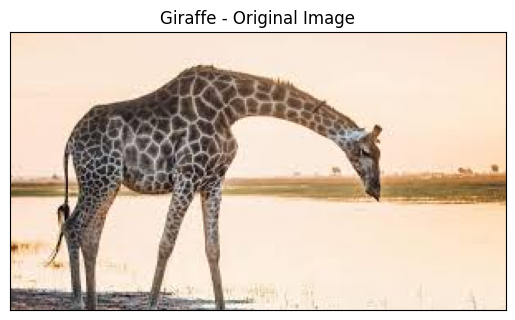

In [383]:
# Load & plot giraffe image
img = read_image(images_path + 'giraffe.jpeg')
img_array = np.asarray(img)
img_array = np.transpose(img_array, (1,2,0))
plt.imshow(img_array)
plt.title('Giraffe - Original Image')
plt.xticks([])
plt.yticks([]);

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0007002..2.5179958].


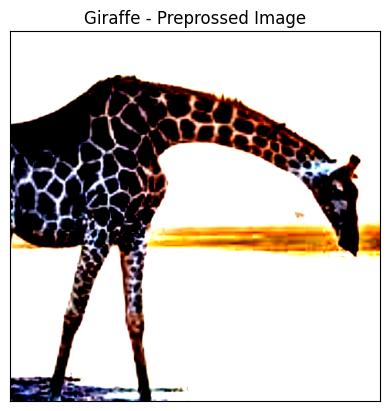

In [384]:
# Plot preprocessed image
img_prep = preprocess(img)
img_prep_array = np.asarray(img_prep)
img_prep_array = np.transpose(img_prep_array, (1,2,0))
plt.imshow(img_prep_array)
plt.title('Giraffe - Preprossed Image')
plt.xticks([])
plt.yticks([]);

<br>
After looking at the preprocessed image, it appears that the model could have correctly classified it as a giraffe.
<br>
<br>

---

### Question 9

In [18]:
# Load dataset
nyse = load_data('NYSE')

# Adapt column names
nyse.columns = [x.lower() for x in nyse.columns]

# Create a feature matrix
cols = ['dj_return', 'log_volume', 'log_volatility']
X = pd.DataFrame(
    StandardScaler(with_mean=True, with_std=True).fit_transform(nyse[cols]),
    columns=cols,
    index=nyse.index
)

In [19]:
# Create a lagged matrix
matrix = X.copy()
for lag in range(5, 0, -1):
    for col in cols:
        col_new = np.zeros(X.shape[0]) * np.nan
        col_new[lag:] = X[col].values[:-lag]
        matrix[f'{col}_{lag}'] = col_new

# Get index
matrix.index = X.index

# Add train indicator
matrix.insert(matrix.shape[1], 'train', nyse['train'])

# Remove nan values
matrix.dropna(inplace=True)

In [20]:
# Create response & training indicator
y, train = matrix['log_volume'], matrix['train']
matrix = matrix.drop(columns=['train'] + cols)

In [21]:
# Create a model
model = LinearRegression()
model.fit(matrix[train], y[train])
model.score(matrix[~train], y[~train])

0.4128912938562521

In [22]:
# Add month to the dataset
X_month = matrix.copy()
month = [x[5:7] for x in X_month.index]
X_month['month'] = month

# Transform month into dummies
X_month = pd.get_dummies(X_month, dtype='int', drop_first=True)

In [23]:
# Create a model
model_month = LinearRegression()
model_month.fit(X_month[train], y[train])
model_month.score(X_month[~train], y[~train])

0.4167123048568927

The model performs better when months are included as features compared to the alternative.

Next, let's test the model again by incorporating weekdays as additional features.

<br>

In [24]:
# Add weekday
X_day = pd.merge(
    matrix,
    nyse['day_of_week'],
    how='inner',
    left_on=matrix.index,
    right_on=nyse.index
)
X_day.index = X_day['key_0']
X_day.drop(columns='key_0', inplace=True)

# Get dummies
X_day = pd.get_dummies(X_day, drop_first=True, dtype='int')

In [25]:
# Create a model
model_day = LinearRegression()
model_day.fit(X_day[train], y[train])
model_day.score(X_day[~train], y[~train])

0.4595563133053271

In [26]:
# Get month columns to join with weekday
columns = X_month.columns[15:]

# Join weekday with month
X_day_month = pd.merge(
    X_day,
    X_month[columns],
    how='inner',
    left_on=X_day.index,
    right_on=X_month.index
)
X_day_month.index = X_day_month['key_0']
X_day_month.drop(columns='key_0', inplace=True)

In [27]:
# Create a model
model_day_month = LinearRegression()
model_day_month.fit(X_day_month[train], y[train])
model_day_month.score(X_day_month[~train], y[~train])

0.4626836082042721

We also see an improvement in the model's performance when adding month features compared to using only weekday.

In both cases, incorporating month features enhances the model's accuracy.

<br>

---

### Question 10

In [37]:
# Reshape data for RNN
X_rnn = matrix.to_numpy().reshape((-1, 5, 3))
X_rnn.shape

(6046, 5, 3)

In [61]:
# Create tensor datasets
datasets = []
for mask in [train, ~train]:
    X_rnn_t = torch.tensor(np.asarray(X_rnn[mask]).astype(np.float32))
    y_t = torch.tensor(np.asarray(y[mask]).astype(np.float32))
    datasets.append(TensorDataset(X_rnn_t, y_t))

# Get train/test
nyse_train, nyse_test = datasets

# Create a datamodule
nyse_dm = SimpleDataModule(
    nyse_train,
    nyse_test,
    num_workers=4,
    validation=nyse_test,
    batch_size=64
)

In [68]:
# Create the architecture
class LinearARModel(nn.Module):
    def __init__(self):
        super(LinearARModel, self).__init__()
        self.flatten = nn.Flatten()
        self.dense = nn.Linear(15, 1)

    def forward(self, x):
        return torch.squeeze(self.dense(self.flatten(x)))

# Instantiate the model
model = LinearARModel()

# Inspect model's summary
summary(
    model, 
    input_data=X_rnn_t, 
    col_names=['input_size', 'output_size', 'num_params'],
    col_width=16
)

Layer (type:depth-idx)                   Input Shape      Output Shape     Param #
LinearARModel                            [1770, 5, 3]     [1770]           --
├─Flatten: 1-1                           [1770, 5, 3]     [1770, 15]       --
├─Linear: 1-2                            [1770, 15]       [1770, 1]        16
Total params: 16
Trainable params: 16
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.03
Input size (MB): 0.11
Forward/backward pass size (MB): 0.01
Params size (MB): 0.00
Estimated Total Size (MB): 0.12

In [71]:
# Set optimizer
nyse_optimizer = RMSprop(model.parameters(), lr=0.001)

# Set up a regression module
nyse_module = SimpleModule.regression(
    model,
    optimizer=nyse_optimizer,
    metrics={'r2':R2Score()}
)

# Create trainer
nyse_trainer = Trainer(
    deterministic=True,
    max_epochs=30,
    callbacks=[ErrorTracker()]
)

# Fit/train model
nyse_trainer.fit(nyse_module, datamodule=nyse_dm)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type          | Params | Mode 
------------------------------------------------
0 | model | LinearARModel | 16     | train
1 | loss  | MSELoss       | 0      | train
------------------------------------------------
16        Trainable params
0         Non-trainable params
16        Total params
0.000     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                               | 0/? [00:00<?, ?it/s]

Training: |                                                                      | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

...

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


In [72]:
# Get 'test' metrics
nyse_trainer.test(nyse_module, datamodule=nyse_dm)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |                                                                       | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.6193413138389587     │
│          test_r2          │    0.41221487522125244    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.6193413138389587, 'test_r2': 0.41221487522125244}]

Both models provide similar $R^2$ of approximately 0.412, which is expected since they optimize the same objective function. The difference between them is their optimization process: one employes Ordinary Least Squares (OLS) to minimize the least squares function, while the other performs Gradient Descent.

The LinearRegression() approach is faster, more computational efficient, and requires less data to provide a reliable solution. It is easier to understand and works well for simple, linear relationships with relatively few features and minimal complexity.

On the other hand, Neural Networks can model more complex, non-linear patterns that traditional regression struggles to capture. However, this flexibility comes at a cost of higher computational cost, it requires more data to train, and reduced interpretability, often being called of "black box".

---

### Question 11

In [76]:
# Create a non-linear AR model
class NonLinearARModel(nn.Module):
    def __init__(self):
        super(NonLinearARModel, self).__init__()
        self.sequential = nn.Sequential(
            nn.Flatten(),
            nn.Linear(15, 45),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(45, 1)
        )
    def forward(self, x):
        return torch.squeeze(self.sequential(x))

# Instantiate the model
model_nonlinear = NonLinearARModel()

# Inspect model's summary
summary(
    model_nonlinear, 
    input_data=X_rnn_t, 
    col_names=['input_size', 'output_size', 'num_params'],
    col_width=16
)

Layer (type:depth-idx)                   Input Shape      Output Shape     Param #
NonLinearARModel                         [1770, 5, 3]     [1770]           --
├─Sequential: 1-1                        [1770, 5, 3]     [1770, 1]        --
│    └─Flatten: 2-1                      [1770, 5, 3]     [1770, 15]       --
│    └─Linear: 2-2                       [1770, 15]       [1770, 45]       720
│    └─ReLU: 2-3                         [1770, 45]       [1770, 45]       --
│    └─Dropout: 2-4                      [1770, 45]       [1770, 45]       --
│    └─Linear: 2-5                       [1770, 45]       [1770, 1]        46
Total params: 766
Trainable params: 766
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.36
Input size (MB): 0.11
Forward/backward pass size (MB): 0.65
Params size (MB): 0.00
Estimated Total Size (MB): 0.76

In [ ]:
# Set optimizer
optimizer = RMSprop(model_nonlinear.parameters(), lr=0.001)

# Set up a regression module
module = SimpleModule.regression(
    model_nonlinear,
    optimizer=optimizer,
    metrics={'r2':R2Score()}
)

# Create trainer
trainer = Trainer(
    deterministic=True,
    max_epochs=30,
    callbacks=[ErrorTracker()]
)

# Fit/train model
trainer.fit(module, datamodule=nyse_dm)

In [82]:
# Get 'test' metrics
trainer.test(module, datamodule=nyse_dm)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |                                                                       | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.6089873313903809     │
│          test_r2          │    0.4220413565635681     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.6089873313903809, 'test_r2': 0.4220413565635681}]

<br>

We see a 1% increase in accuracy by introducing simple modifications and making the model nonlinear. This highlights the previously discussed potential of Neural Networks in capturing more complex patterns.


---

### Question 12

In [ ]:
# Include day_of_week for the RNN


In [84]:
pd.get_dummies(nyse['day_of_week'], dtype='int')

,mon,tues,wed,thur,fri
date,,,,,
1962-12-03,1,0,0,0,0
1962-12-04,0,1,0,0,0
1962-12-05,0,0,1,0,0
1962-12-06,0,0,0,1,0
1962-12-07,0,0,0,0,1
...,...,...,...,...,...
1986-12-24,0,0,1,0,0
1986-12-26,0,0,0,0,1
1986-12-29,1,0,0,0,0


In [85]:
from sklearn.preprocessing import OneHotEncoder

In [86]:
enc = OneHotEncoder(handle_unknown='ignore')

In [91]:
enc.fit(np.asarray(nyse['day_of_week']).reshape((-1,1)))

OneHotEncoder(handle_unknown='ignore')

In [93]:
enc.transform(np.asarray(nyse['day_of_week']).reshape((-1,1))).toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

In [94]:
enc.transform(np.asarray(nyse['day_of_week']).reshape((-1,1))).toarray().shape

(6051, 5)

In [97]:
0.839**2

0.7039209999999999

In [98]:
0.544**2

0.29593600000000003